# Split temporal y esquema de validación

En el EDA vimos que las operaciones tienen un orden temporal, la tasa de fraude cambia entre días y algunas categorías de j aparecen por primera vez hacia el final. 

No se puede mezclar filas al azar: un modelo de producción siempre se entrena con el pasado y se usa sobre operaciones futuras.

El objetivo de este notebook es dejar una primera estrategia de división para comparar todos los modelos bajo las mismas condiciones. Acá no imputo, escalo, codifico categorías, hago resampling ni creo features para un modelo particular. Esos pasos tienen que aprenderse dentro de cada fold y dependen del modelo.

## 1. Setup

In [31]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (7, 3.5)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.business import ganancia_aprobar_todo
from src.data import TARGET, DEFAULT_DATA_PATH, DEFAULT_PROCESSED_DIR, cargar_datos, convertir_fecha
from src.validation import (
    TEST_END,
    TEST_START,
    crear_folds_temporales,
    mascaras_desarrollo_test,
    mascaras_fold,
    validar_folds,
)

DATA_PATH = DEFAULT_DATA_PATH
PROCESSED_DIR = DEFAULT_PROCESSED_DIR

RANDOM_SEED = 42

In [32]:
df = cargar_datos(DATA_PATH)
fecha = convertir_fecha(df["fecha"])

print(f"Filas: {len(df):,}")
print(f"Rango: {fecha.min()}  ->  {fecha.max()}")
print(f"Fraude global: {df[TARGET].mean():.2%}")

Filas: 150,000
Rango: 2020-03-08 00:02:15  ->  2020-04-21 23:59:56
Fraude global: 5.00%


## 2. Separar primero el test final

Antes de construir los folds, me guardo los últimos siete días como test final: del 15 al 21 de abril. 

El EDA se restringió al período de dev, así que esta semana no fue observada ni siquiera en la exploración.

In [33]:
es_desarrollo, es_test = mascaras_desarrollo_test(fecha)

assert not (es_test & es_desarrollo).any()
assert (es_test | es_desarrollo).all()
assert fecha.loc[es_desarrollo].max() < fecha.loc[es_test].min()

resumen_test = pd.DataFrame({
    "periodo": ["dev set", "test final"],
    "desde": [fecha.loc[es_desarrollo].min(), fecha.loc[es_test].min()],
    "hasta": [fecha.loc[es_desarrollo].max(), fecha.loc[es_test].max()],
    "n": [es_desarrollo.sum(), es_test.sum()],
}).set_index("periodo")
resumen_test["pct_total"] = resumen_test["n"] / len(df)

resumen_test

,desde,hasta,n,pct_total
periodo,,,,
dev set,2020-03-08 00:02:15,2020-04-14 23:59:39,121014,0.8068
test final,2020-04-15 00:00:39,2020-04-21 23:59:56,28986,0.1932


La división deja 121.014 operaciones para dev set, el 80,68% del dataset, y 28.986 para test final, el 19,32%. El porcentaje de test es algo mayor que el 15% o 20% usado a veces en divisiones aleatorias porque acá no elegimos una cantidad exacta de filas: reservamos una semana calendario completa y el volumen diario no es constante.

Una semana completa permite incluir todos los días de la semana y mantiene el orden temporal. Reservar más tiempo reduciría demasiado los datos disponibles para entrenar y validar, reservar menos dejaría una evaluación final muy dependiente de uno o dos días particulares.

## 3. Elegir el esquema de validación

Dentro de desarrollo uso tres folds temporales acumulados, cada uno validando sobre la semana siguiente. Esto deja tres semanas completas de validación y un primer train de 17 días. Agregar más folds reduciría demasiado el train inicial o impediría validar semanas completas. La ventana móvil queda como prueba de sensibilidad para los finalistas.

In [34]:
folds = crear_folds_temporales()

folds

,fold,train_start,train_end,validation_start,validation_end
0,1,2020-03-08,2020-03-25,2020-03-25,2020-04-01
1,2,2020-03-08,2020-04-01,2020-04-01,2020-04-08
2,3,2020-03-08,2020-04-08,2020-04-08,2020-04-15


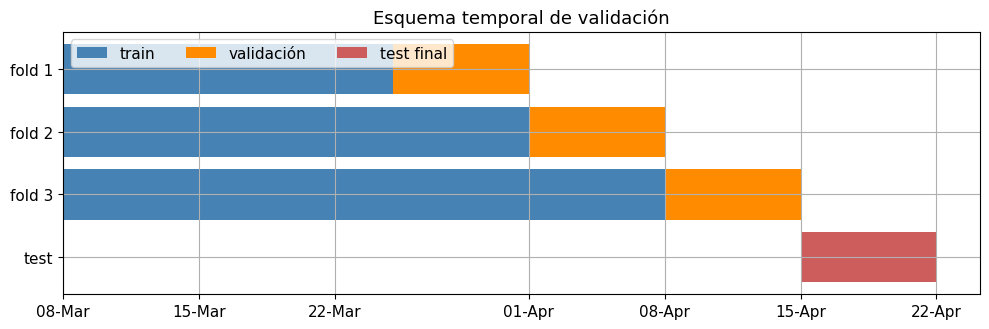

In [35]:
fig, ax = plt.subplots(figsize=(10, 3.4))

for _, fold in folds.iterrows():
    y = 4 - fold["fold"]
    ax.barh(y, fold["train_end"] - fold["train_start"], left=fold["train_start"],
            color="steelblue", label="train" if fold["fold"] == 1 else None)
    ax.barh(y, fold["validation_end"] - fold["validation_start"], left=fold["validation_start"],
            color="darkorange", label="validación" if fold["fold"] == 1 else None)

ax.barh(0, TEST_END - TEST_START, left=TEST_START, color="indianred", label="test final")
ax.set_yticks([3, 2, 1, 0], ["fold 1", "fold 2", "fold 3", "test"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax.set_title("Esquema temporal de validación", fontsize=13)
ax.legend(fontsize=11, ncol=3, loc="upper left")
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.grid()
plt.show()

## 4. Verificar que los folds respeten el tiempo

Antes de mirar resultados, compruebo tres condiciones: train y validación no se superponen, todo train ocurre antes de su validación y ningún fold toca el test final.

In [36]:
chequeos = validar_folds(fecha, folds, es_test)
chequeos["pct_desarrollo_train"] = chequeos["n_train"] / es_desarrollo.sum()
chequeos["pct_desarrollo_validacion"] = chequeos["n_validacion"] / es_desarrollo.sum()
chequeos["pct_total_train"] = chequeos["n_train"] / len(df)
chequeos["pct_total_validacion"] = chequeos["n_validacion"] / len(df)
chequeos

,sin_superposicion,train_antes_de_validacion,sin_filas_de_test,n_train,n_validacion,pct_desarrollo_train,pct_desarrollo_validacion,pct_total_train,pct_total_validacion
fold,,,,,,,,,
1,True,True,True,60424,16537,0.4993,0.1367,0.4028,0.1102
2,True,True,True,76961,20282,0.6360,0.1676,0.5131,0.1352
3,True,True,True,97243,23771,0.8036,0.1964,0.6483,0.1585


Los tamaños cambian con el volumen de cada semana. Train y validación no suman todo desarrollo porque las fechas posteriores a cada fold todavía representan futuro y se incorporan recién en los folds siguientes.

## 5. Qué tan distintos son los folds

En esta sección uso solamente dev. Para cada train y validación calculo tamaño, fraude, monto, score, faltantes de o y la ganancia de aprobar todo. Esta última funciona como referencia propia de cada período: si cambia la mezcla de operaciones, también puede cambiar la ganancia base.

In [37]:
def resumir_periodo(mask):
    parte = df.loc[mask]
    ganancia_base = ganancia_aprobar_todo(parte[TARGET], parte["monto"])

    return {
        "n": len(parte),
        "tasa_fraude": parte[TARGET].mean(),
        "monto_mediana": parte["monto"].median(),
        "monto_medio": parte["monto"].mean(),
        "score_medio": parte["score"].mean(),
        "pct_o_faltante": parte["o"].isna().mean(),
        "ganancia_aprobar_todo": ganancia_base,
    }


filas_resumen = []
for _, fold in folds.iterrows():
    train, validacion = mascaras_fold(fecha, fold)
    for nombre, mask in [("train", train), ("validación", validacion)]:
        fila = {"fold": int(fold["fold"]), "periodo": nombre}
        fila.update(resumir_periodo(mask))
        filas_resumen.append(fila)

resumen_folds = pd.DataFrame(filas_resumen).set_index(["fold", "periodo"])
resumen_folds

n  tasa_fraude  monto_mediana  monto_medio  score_medio  \
fold periodo                                                                   
1    train       60424       0.0476        23.3500      47.0585      51.2765   
     validación  16537       0.0605        19.6700      41.0583      50.0892   
2    train       76961       0.0504        22.3800      45.7692      51.0214   
     validación  20282       0.0564        18.2200      40.7889      45.5203   
3    train       97243       0.0516        21.5000      44.7304      49.8740   
     validación  23771       0.0522        18.4700      39.7904      44.9342   

                 pct_o_faltante  ganancia_aprobar_todo  
fold periodo                                            
1    train               0.7259           439,753.7550  
     validación          0.7217            88,131.9200  
2    train               0.7250           527,885.6750  
     validación          0.7241           101,294.0225  
3    train               0.7248           629,179.6975  
     validación          0.7224           127,601.7175

Los folds no presentan exactamente la misma dificultad. La tasa de fraude de validación es mayor en los dos primeros períodos y se acerca a train en el tercero. El monto mediano y el score medio también bajan hacia las validaciones más recientes. Esto es justamente lo que el split aleatorio habría mezclado y ocultado.

Por eso no conviene elegir un modelo mirando solamente su mejor semana. Se verá la ganancia acumulada de las tres validaciones y también su variación entre folds.

## 6. Categorías de j no vistas en train

En cada fold cuento qué parte de las categorías de j y operaciones de validación no existía todavía en su train

In [38]:
novedad_j = []
for _, fold in folds.iterrows():
    train, validacion = mascaras_fold(fecha, fold)
    categorias_train = set(df.loc[train, "j"])
    categorias_validacion = pd.Index(df.loc[validacion, "j"].unique())

    novedad_j.append({
        "fold": int(fold["fold"]),
        "categorias_validacion": len(categorias_validacion),
        "pct_categorias_nuevas": (~categorias_validacion.isin(categorias_train)).mean(),
        "pct_operaciones_con_categoria_nueva": (
            ~df.loc[validacion, "j"].isin(categorias_train)
        ).mean(),
    })

novedad_j = pd.DataFrame(novedad_j).set_index("fold")
novedad_j

,categorias_validacion,pct_categorias_nuevas,pct_operaciones_con_categoria_nueva
fold,,,
1,3472,0.1322,0.0317
2,3858,0.1151,0.0252
3,4161,0.1154,0.0225


Entre 11% y 13% de las categorías de cada validación son nuevas, pero representan aproximadamente entre 2% y 3% de sus operaciones. La mayoría de las filas pertenece a niveles conocidos, aunque el caso de categorías no vistas es lo bastante frecuente como para medirlo por separado en modelado.

## 7. Guardar la configuración de los folds

La fecha de la operación y los límites de cada fold alcanzan para reconstruir train, validación y test siempre de la misma manera.

Guardo esa tabla de límites como referencia. En el notebook de modelado se cargarán estas fechas y cada preprocesamiento se ajustará desde cero usando solo el train correspondiente. No se guarda ninguna feature transformada.

In [39]:
configuracion_folds = folds.copy()

In [40]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

configuracion_folds.to_csv(PROCESSED_DIR / "validation_folds.csv", index=False)

print(f"Guardado: {PROCESSED_DIR / 'validation_folds.csv'}")

Guardado: C:\xampp\htdocs\meli-fraud-prevention-challenge\data\processed\validation_folds.csv


## 8. Decisiones para modelado

El esquema queda fijado así:

1. Todos los modelos usarán los mismos tres folds temporales acumulados.
2. Cada validación cubre siete días y ocurre después de su train.
3. El período del 15 al 21 de abril queda reservado para la evaluación final.
4. Imputación, escalado, encoding, agrupación de categorías y cualquier resampling se ajustarán dentro de cada fold, nunca sobre el dataset completo.
5. La comparación considerará ganancia acumulada y estabilidad entre folds, no solo el mejor resultado individual.
6. El comportamiento de categorías de j no vistas se reportará por separado.
7. Una ventana móvil podrá evaluarse más adelante con los finalistas, sin cambiar el esquema principal usado para compararlos.

El próximo notebook empezará con políticas simples y regresión logística.